In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)
import joblib

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [2]:
#loading models
log_model = joblib.load("../results/logistic_model.pkl")

rf_model = joblib.load("../results/random_forest_model.pkl")

xgb_model = joblib.load("../results/xgboost_model.pkl")

scaler = joblib.load("../results/scaler.pkl")

X_train, X_test, y_train, y_test = joblib.load(
    "../results/train_test_split.pkl"
)

In [3]:
#Scale logistic regression
X_test_scaled = scaler.transform(X_test)

In [4]:
#Generates Predictions

#logistic regression
log_predictions = log_model.predict(X_test_scaled)

log_probabilities = log_model.predict_proba(
    X_test_scaled
)[:,1]

#RF
rf_predictions = rf_model.predict(X_test)

rf_probabilities = rf_model.predict_proba(
    X_test
)[:,1]

#XG
xgb_predictions = xgb_model.predict(X_test)

xgb_probabilities = xgb_model.predict_proba(
    X_test
)[:,1]

In [5]:
#Logistics Classification Report
print("Logistic Regression\n")

print(classification_report(
    y_test,
    log_predictions
))

Logistic Regression

              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1270881
           1       0.02      0.96      0.05      1643

    accuracy                           0.95   1272524
   macro avg       0.51      0.96      0.51   1272524
weighted avg       1.00      0.95      0.97   1272524



In [6]:
#RF
print("Random Forest\n")

print(classification_report(
    y_test,
    rf_predictions
))

Random Forest

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       1.00      1.00      1.00      1643

    accuracy                           1.00   1272524
   macro avg       1.00      1.00      1.00   1272524
weighted avg       1.00      1.00      1.00   1272524



In [7]:
#XGBoost
print("XGBoost\n")

print(classification_report(
    y_test,
    xgb_predictions
))

XGBoost

              precision    recall  f1-score   support

           0       1.00      0.99      1.00   1270881
           1       0.18      0.99      0.30      1643

    accuracy                           0.99   1272524
   macro avg       0.59      0.99      0.65   1272524
weighted avg       1.00      0.99      1.00   1272524



In [8]:
#ROC-AUC
log_auc = roc_auc_score(y_test, log_probabilities)
rf_auc = roc_auc_score(y_test, rf_probabilities)
xgb_auc = roc_auc_score(y_test, xgb_probabilities)

print(f"Logistic Regression ROC-AUC: {log_auc:.4f}")
print(f"Random Forest ROC-AUC: {rf_auc:.4f}")
print(f"XGBoost ROC-AUC: {xgb_auc:.4f}")

Logistic Regression ROC-AUC: 0.9907
Random Forest ROC-AUC: 0.9991
XGBoost ROC-AUC: 0.9946


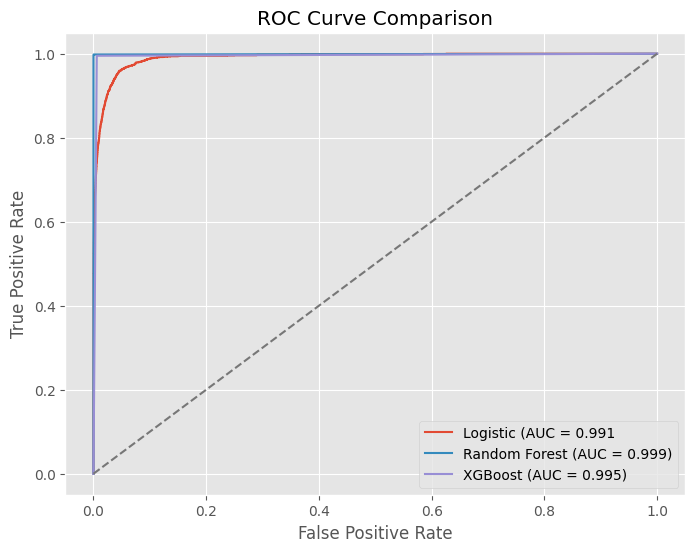

In [9]:
#ROC Curve
log_fpr, log_tpr, _ = roc_curve(y_test, log_probabilities)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probabilities)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probabilities)

plt.figure(figsize=(8,6))

plt.plot(log_fpr, log_tpr, label=f"Logistic (AUC = {log_auc:.3f}")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.3f})")
plt.plot(xgb_fpr, xgb_tpr, label=f"XGBoost (AUC = {xgb_auc:.3f})")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.savefig(
    "../images/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

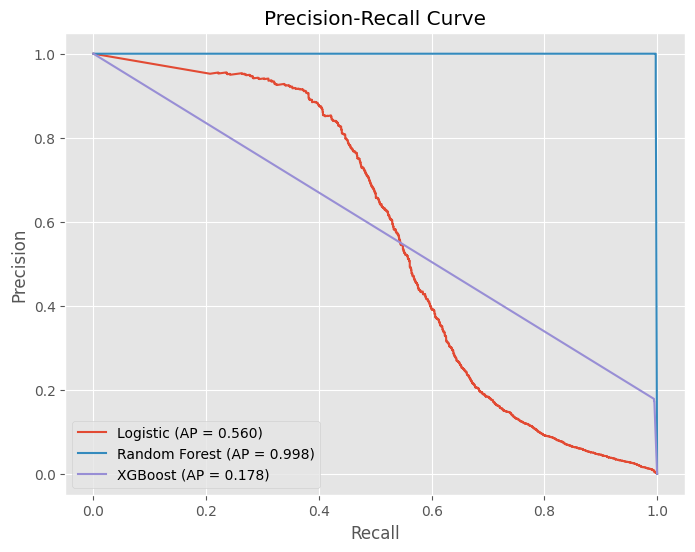

In [10]:
#Precision Recall Curve
from sklearn.metrics import precision_recall_curve, average_precision_score

log_precision, log_recall, _ = precision_recall_curve(
    y_test, log_probabilities
)

rf_precision, rf_recall, _ = precision_recall_curve(
    y_test, rf_probabilities
)

xgb_precision, xgb_recall, _ = precision_recall_curve(
    y_test, xgb_probabilities
)

log_ap = average_precision_score(y_test, log_probabilities)
rf_ap = average_precision_score(y_test, rf_probabilities)
xgb_ap = average_precision_score(y_test, xgb_probabilities)

plt.figure(figsize=(8,6))

plt.plot(log_recall, log_precision,
         label=f"Logistic (AP = {log_ap:.3f})")

plt.plot(rf_recall, rf_precision,
         label=f"Random Forest (AP = {rf_ap:.3f})")

plt.plot(xgb_recall, xgb_precision,
         label=f"XGBoost (AP = {xgb_ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.legend()

plt.savefig(
    "../images/precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
metrics = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Precision": [
        precision_score(y_test, log_predictions),
        precision_score(y_test, rf_predictions),
        precision_score(y_test, xgb_predictions)
    ],
    "Recall": [
        recall_score(y_test, log_predictions),
        recall_score(y_test, rf_predictions),
        recall_score(y_test, xgb_predictions)
    ],
    "F1 Score": [
        f1_score(y_test, log_predictions),
        f1_score(y_test, rf_predictions),
        f1_score(y_test, xgb_predictions)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, log_probabilities),
        roc_auc_score(y_test, rf_probabilities),
        roc_auc_score(y_test, xgb_probabilities)
    ],
    "Average Precision": [
        average_precision_score(y_test, log_probabilities),
        average_precision_score(y_test, rf_probabilities),
        average_precision_score(y_test, xgb_probabilities)
    ]
})

metrics

,Model,Precision,Recall,F1 Score,ROC-AUC,Average Precision
0,Logistic Regression,0.024034,0.962873,0.046897,0.990706,0.559633
1,Random Forest,1.000000,0.997565,0.998781,0.999086,0.998019
2,XGBoost,0.176230,0.994522,0.299404,0.994618,0.178317


In [12]:
## Model Selection

# Random Forest achieved the strongest overall performance across evaluation metrics

# The model achieved a precision of 100%, recall of 99.8%, and an average precision score of 99.8% 
# Demonstrated its ability to identify fraudulent transactions while minimizing false positives

# Logistic Regression provided a useful baseline model, achieved high recall but generated a large number of false positive alerts

# XGBoost also achieved strong fraud detection recall
# Its lower precision resulted in a higher number of false positives. This suggests that additional threshold tuning may be needed before deployment

# Based on these results, Random Forest was selected as the preferred fraud detection model for this dataset

In [13]:
#Save
metrics.to_csv(
    "../results/model_metrics.csv",
    index=False
)

In [14]:
#Confusion Matrix
def plot_confusion_matrix(y_true, y_pred, title, filename):
    
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.savefig(
        f"../images/{filename}",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

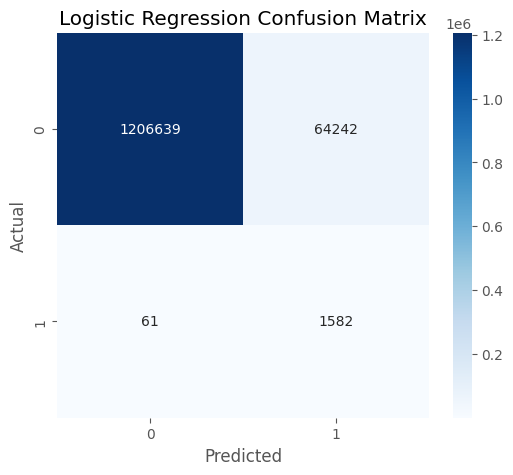

In [15]:
#LR
plot_confusion_matrix(
    y_test,
    log_predictions,
    "Logistic Regression Confusion Matrix",
    "logistic_confusion_matrix.png"
)

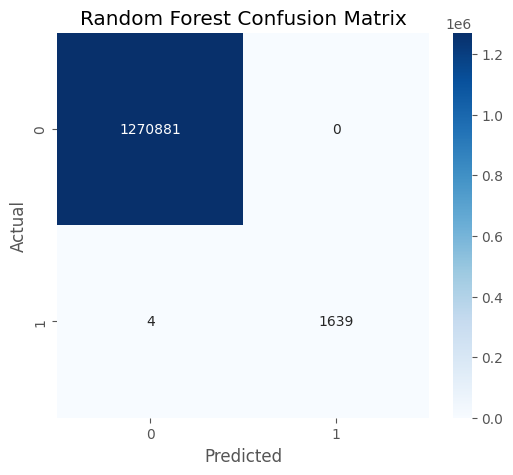

In [16]:
#RF
plot_confusion_matrix(
    y_test,
    rf_predictions,
    "Random Forest Confusion Matrix",
    "rf_confusion_matrix.png"
)

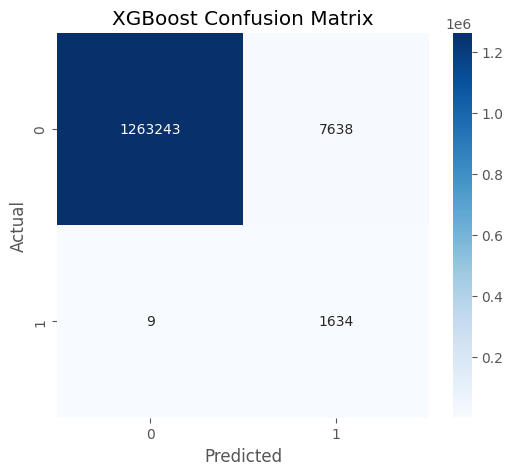

In [17]:
#XGBoost
plot_confusion_matrix(
    y_test,
    xgb_predictions,
    "XGBoost Confusion Matrix",
    "xgb_confusion_matrix.png"
)

In [18]:
print("Logistic Regression")
print(confusion_matrix(y_test, log_predictions))

print("\nRandom Forest")
print(confusion_matrix(y_test, rf_predictions))

print("\nXGBoost")
print(confusion_matrix(y_test, xgb_predictions))

Logistic Regression
[[1206639   64242]
 [     61    1582]]

Random Forest
[[1270881       0]
 [      4    1639]]

XGBoost
[[1263243    7638]
 [      9    1634]]


In [19]:
## Confusion Matrix Analysis

# The confusion matrices highlight the tradeoff between detecting fraud and minimizing false alerts

# Logistic Regression detected most fraudulent transactions but generated a large number of false positives, 
# making it impractical for a fraud investigation workflow

# XGBoost achieved the highest fraud recall, detecting 99.5% of fraudulent transactions, but produced more false alerts than Random Forest

# Random Forest achieved the strongest balance, identifying 1,639 out of 1,643 fraudulent transactions while producing zero false positives
# Based on these results, Random Forest was selected as the preferred model

In [20]:
#RF Feature Importance
rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

rf_importance.head(10)


,Feature,Importance
10,origin_balance_error,0.284754
6,origin_balance_change,0.215339
8,origin_balance_removed_pct,0.162792
3,newbalanceOrig,0.086722
2,oldbalanceOrg,0.077864
1,amount,0.045765
15,type_PAYMENT,0.029553
12,high_value_transaction,0.021733
7,destination_balance_change,0.018171
16,type_TRANSFER,0.013482


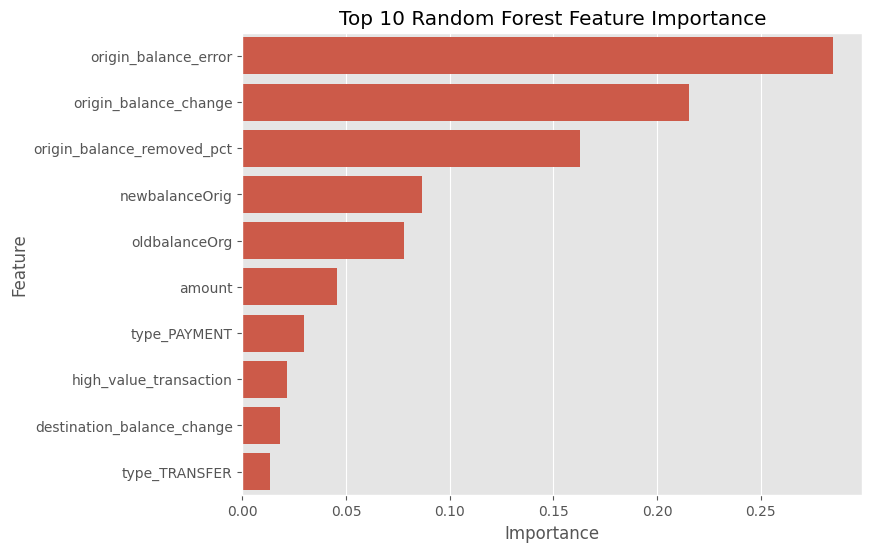

In [21]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=rf_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.savefig(
    "../images/rf_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
## Random Forest Feature Importance Analysis

# The Random Forest model relied heavily on features related to sender account balance behavior

# The strongest predictor was 'origin_balance_error', followed by 'origin_balance_change' and 'origin_balance_removed_pct'
# This suggests that abnormal account balance movement patterns are key indicators of fraudulent activity

# Transaction amount was also an important predictor, 
# This supports earlier exploratory analysis showing that fraudulent transactions tend to involve larger amounts

# The feature importance results align with the EDA findings 
# and demonstrate that engineered behavioral features improved the model's ability to identify suspicious transactions

In [23]:
#XGBoost Feature Importance
xgb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

xgb_importance.head(10)

,Feature,Importance
5,newbalanceDest,0.352057
10,origin_balance_error,0.228733
3,newbalanceOrig,0.149986
4,oldbalanceDest,0.098810
1,amount,0.045750
11,destination_balance_error,0.044540
2,oldbalanceOrg,0.022826
0,step,0.011347
6,origin_balance_change,0.011066
12,high_value_transaction,0.010559


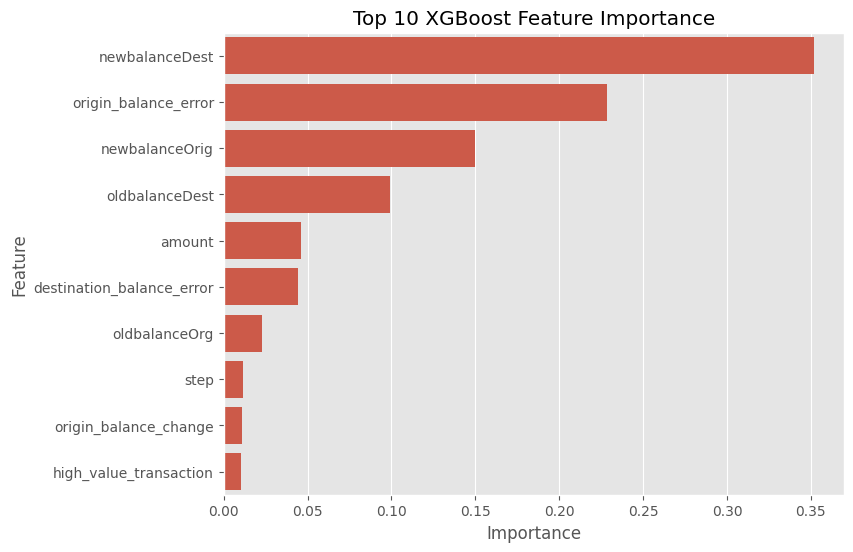

In [24]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=xgb_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.savefig(
    "../images/xgb_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
## XGBoost Feature Importance Analysis

# The XGBoost model relied heavily on destination account balance information, particularly 'newbalanceDest' and 'oldbalanceDest'

# This differs slightly from the Random Forest model, which placed more emphasis on sender balance changes

# Both models identified account balance behavior as the strongest signal for fraud detection
# This reinforces the importance of transaction flow patterns in identifying suspicious activity

In [26]:
#Save
rf_importance.to_csv(
    "../results/rf_feature_importance.csv",
    index=False
)

xgb_importance.to_csv(
    "../results/xgb_feature_importance.csv",
    index=False
)